<a href="https://colab.research.google.com/github/Nyauntu/Data-science-practice/blob/main/Copy_of_T7_Classification_Model_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Assessment


**Data Science for Business - Instructor:  Chris Volinsky**

**Original Notebooks courtesy of Prof. Foster Provost and Rubing Li**

***

Import all of the packages we will need.

In [1]:
# Import the libraries we will be using
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split


import matplotlib.pylab as plt
%matplotlib inline
# plt.rcParams['figure.figsize'] = 15, 12

### Data Input, EDA, and Data Cleaning
We're going to use a mail response data set from a real direct marketing campaign.  [You can download the data here](https://drive.google.com/uc?export=download&id=1deEx-Ey37F7qznPlIqmaAjjkmkvBtV28).  Each record represents an individual who was targeted with a direct marketing offer.  The offer was a solicitation to make a charitable donation.

The columns (features) are:

```
income       household income
Firstdate    date of first gift by this individual
Lastdate     date of the most recent gift
Amount       average amount donated by this individual over all periods
rfaf2        frequency code
rfaa2        donation amount code
pepstrfl     flag indicating a star donator
glast        amount of last gift
gavr         amount of average gift
```

The target feature is `class` and is equal to one if they gave in this campaign and zero otherwise.

In [2]:
# Read the data into Colab

df = pd.read_csv('DirectMarketing.csv')


In [3]:
df.head()
#df.describe().round(2)

,Income,Firstdate,Lastdate,Amount,rfaf2,rfaa2,pepstrfl,glast,gavr,class
0,3,9409.0,9509.0,0.06,1.0,G,0,50.0,30.00,0.0
1,2,9201.0,9602.0,0.16,4.0,G,X,20.0,20.55,1.0
2,0,9510.0,9603.0,0.20,4.0,E,0,5.0,8.75,0.0
3,6,9409.0,9603.0,0.13,2.0,G,0,25.0,22.50,0.0
4,0,9310.0,9511.0,0.10,1.0,G,0,25.0,12.50,0.0


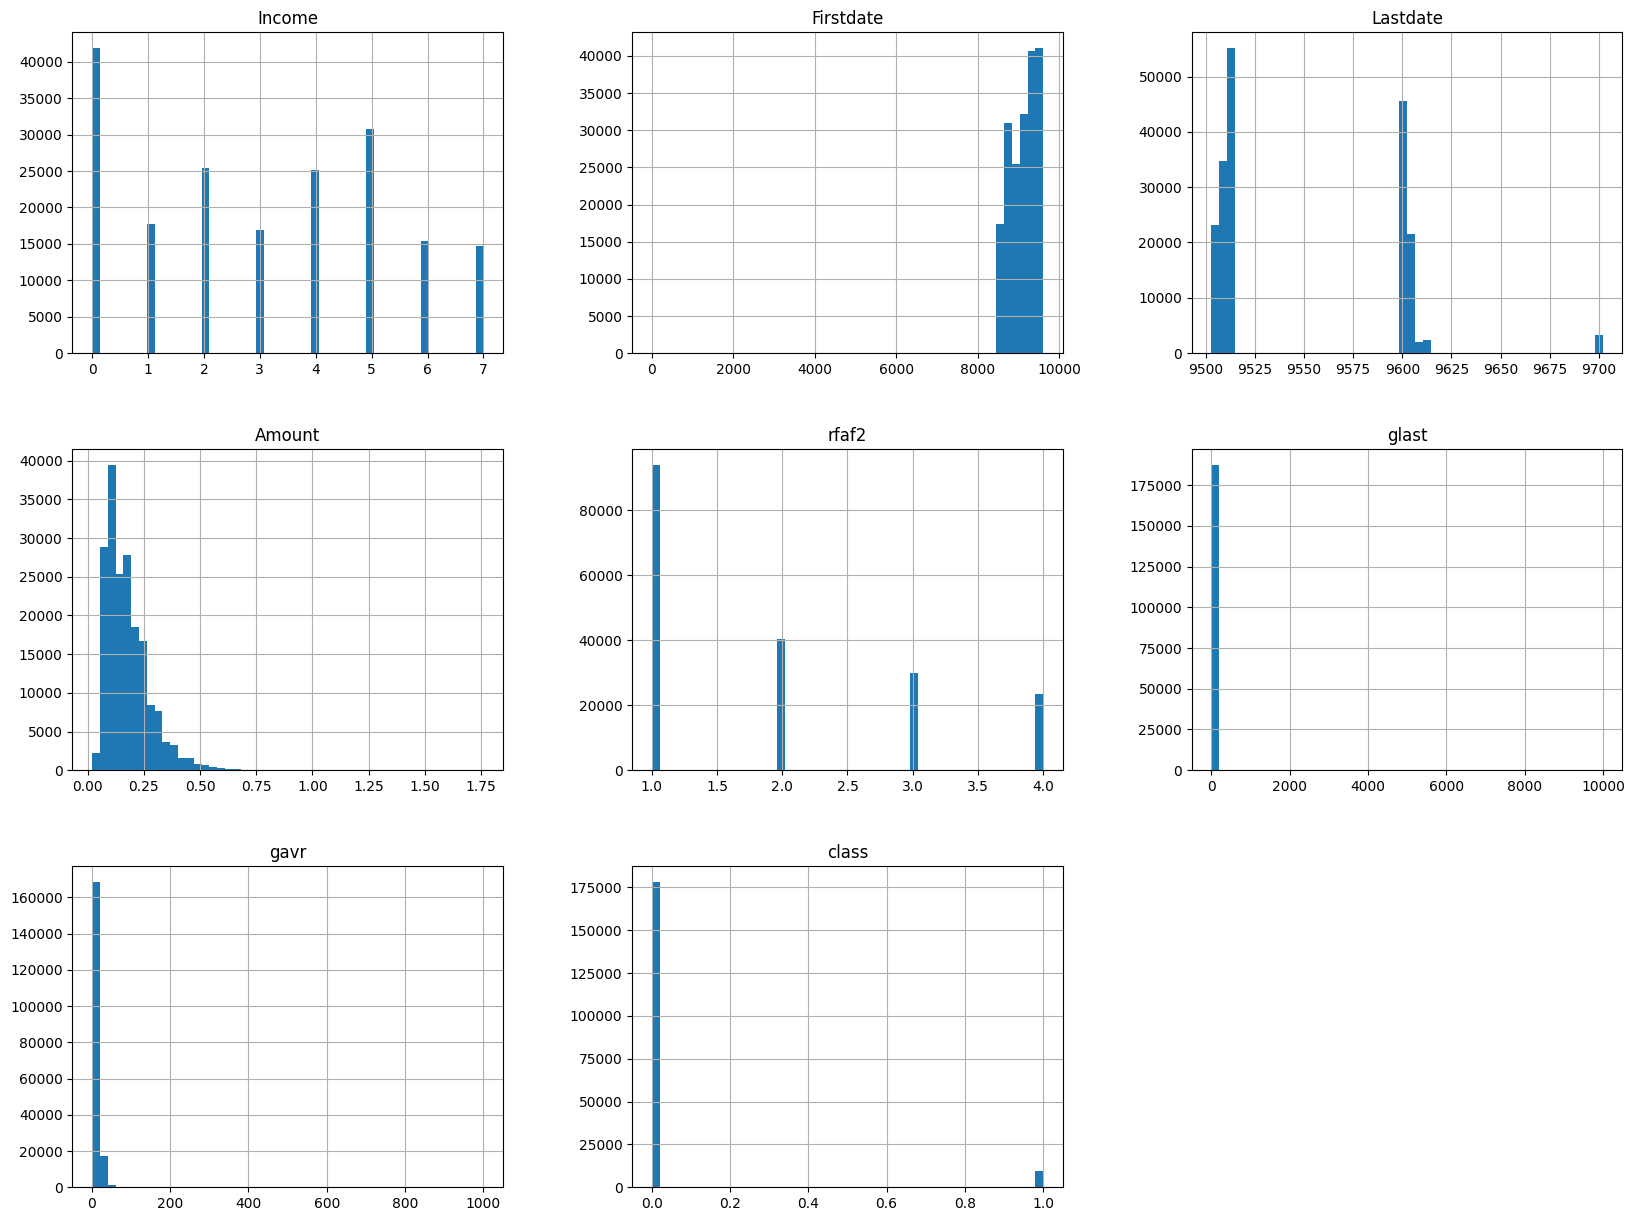

In [4]:
#plot histograms of all features

df.hist(bins=50, figsize=(20, 15))
plt.show()

We need to do some cleaning here...

- There are no missing values, but there are 4 cases where Firstdate is zero.  We can remove those.

- We have two heavily skewed features - `gavr` and `glast` - where we might want to consider transformations.  We will be fitting a regression model, so it is best not to have skewed features.

- our target is unbalanced (5% class == 1), we might consider balancing it, but for now, no.

- need to create dummies for our categorical features (rfaa2 and pepstrfl), but there are others that are also categorical but not coded that way (income and rfaf2)

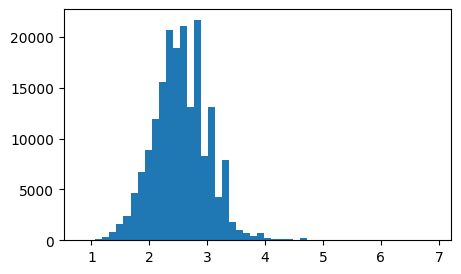

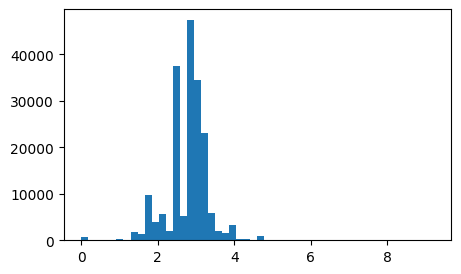

In [5]:

# replace gavr and glast with log versions of same features using np.log() and plot

df_clean = df.copy()
df_clean['gavr'] = np.log(df_clean.gavr+1)
df_clean['glast'] = np.log(df_clean.glast+1)
plt.figure(figsize=(5,3))
plt.hist(np.log(df.gavr+1), bins=50,ec='black')
plt.figure(figsize=(5,3))
plt.hist(np.log(df.glast+1), bins=50,ec='black')
plt.show()



We want to create dummies for all of our categorical features.  But two of them (Income and rfaf2) are not yet recognized as categorical.  So we need to change them, and then create the dummies, for them and the other features `rfaa2` and `pepstrfl`.

Use `drop_first=True` to create k-1 dummies as required for regression models.

In [6]:
income_cat = pd.Categorical(df['Income'], categories=[0,1,2,3,4,5,6,7], ordered=True)
df_clean['Income'] = income_cat

rfaf2_cat = pd.Categorical(df['rfaf2'], categories=[1,2,3,4], ordered=True)
df_clean['rfaf2'] = rfaf2_cat

df_clean = pd.get_dummies(df_clean, columns=['rfaa2', 'pepstrfl','Income','rfaf2'],drop_first=True)
df_clean.head()


,Firstdate,Lastdate,Amount,glast,gavr,class,rfaa2_E,rfaa2_F,rfaa2_G,pepstrfl_X,Income_1,Income_2,Income_3,Income_4,Income_5,Income_6,Income_7,rfaf2_2,rfaf2_3,rfaf2_4
0,9409.0,9509.0,0.06,3.931826,3.433987,0.0,False,False,True,False,False,False,True,False,False,False,False,False,False,False
1,9201.0,9602.0,0.16,3.044522,3.070376,1.0,False,False,True,True,False,True,False,False,False,False,False,False,False,True
2,9510.0,9603.0,0.20,1.791759,2.277267,0.0,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,9409.0,9603.0,0.13,3.258097,3.157000,0.0,False,False,True,False,False,False,False,False,False,True,False,True,False,False
4,9310.0,9511.0,0.10,3.258097,2.602690,0.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False


Look at the date features Firstdate and Lastdate...what do you think these are?  First we need to encode them properly, and take out weird values


In [7]:
# Convert 'Firstdate' and 'Lastdate' to datetime in YYMM format

# remove any records with Firstdate = = or before 1980
df_clean = df_clean[df_clean.Firstdate > 8000]

# import using correct format
df_clean['Firstdate'] = pd.to_datetime(df_clean['Firstdate'], format='%y%m', errors='coerce')

df_clean['Lastdate'] = pd.to_datetime(df_clean['Lastdate'], format='%y%m', errors='coerce')

Now, lets think about "feature engineering" - other info we can extract from the dates.  Often the dates themselves are not the interesting values, but things that we can calculate from the dates.   Things that are often useful : how long have they been a customer?  When was the last time we heard from them?  

Maybe let:

*tenure* = Lastdate-Firstdate

and

*recency* = Today-Lastdate


In [8]:
# Create a new feature 'tenure'
tenure = df_clean['Lastdate'] - df_clean['Firstdate']

# tenure is coded as type Timedelta, need to convert to numeric:
df_clean['tenure'] = tenure.dt.days

# maybe check to see this is always greater than zero?
df_clean['tenure'].min()

0

In [9]:
# assign "today" as the max value of Lastdate, and calculate "recency" as the difference between today and Lastdate

today = df_clean['Lastdate'].max()

df_clean['recency'] = (today - df_clean['Lastdate']).dt.days

# remove Firstdate and Lastdate cause we dont need em
df_clean = df_clean.drop(['Firstdate', 'Lastdate'], axis=1)


### Build the Classification model

We are going to build a Classification model to predict the target `class`
Our model will be **Logistic Regression** - which despite its name is *actually* a type of classification model 🤯 - more on this later.   

Our model will provide predictions and probabilities, but is not useful until we apply *decision logic*, specfically defining the threshold that we will use to determine the action we will take.

In [10]:
# Split our data into training and test sets
# remove the features we dont need anymore from our X features

X = df_clean.drop(['class'], axis=1)
Y = df_clean['class']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.2, random_state=13)

# Make and fit a model on the training data

model_lr = LogisticRegression(C=100000,solver = 'liblinear')
  # C is a regularlization parameter, will discuss in next chapter
  # liblinear is a good general purpose solver (algorithm)
model_lr.fit(X_train, Y_train)

# Extract probabilities of being a donor using predict_proba()
probabilities = model_lr.predict_proba(X_test)[:, 1]

Lets think about what threshold to use!  Default is 0.5.

(An individual below this threshold will get a prediction of "0" and someone above this will get a prediction of "1")

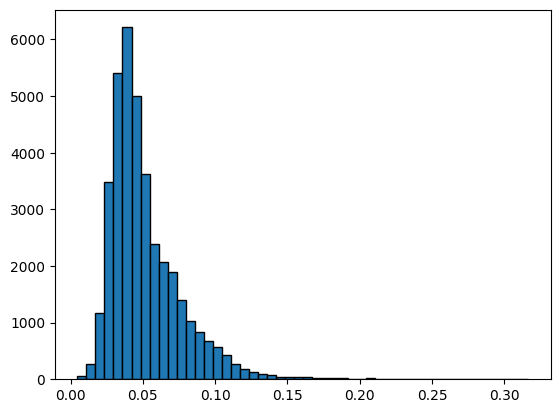

In [11]:
#plot histogram of probabilities
plt.hist(probabilities, bins=50,edgecolor='black')
plt.show()

What do you notice about the probabilities?

Here is an example where using a 0.5 threshold does not make sense!  

How well does my model separate true givers vs non givers?  <b>Plot boxplots of the probability of givers vs non-givers</b>  and use that plus the histogram to pick a sensible threshold below to define the label that comes out of the model.


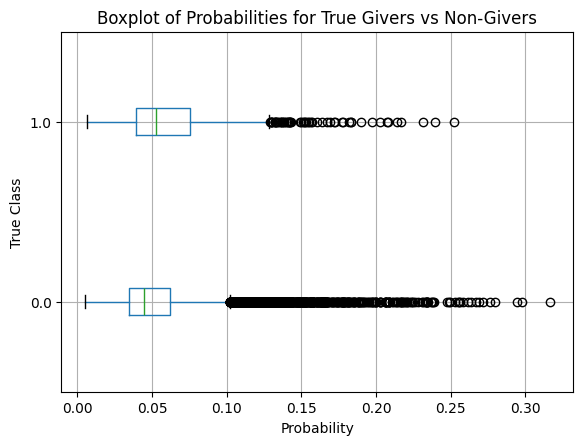

In [12]:
## Plot boxplot of probabilities for true 0 vs 1.

# Create a DataFrame for easier plotting
df_probs = pd.DataFrame({'Probability': probabilities, 'True_Class': Y_test})

# Plot boxplot
df_probs.boxplot(column='Probability', by='True_Class', vert=False)
plt.title('Boxplot of Probabilities for True Givers vs Non-Givers')
plt.suptitle('') # Suppress the default boxplot title
plt.xlabel('Probability')
plt.ylabel('True Class')
plt.show()

In [13]:
thresh = 0.08

pred_giver = probabilities > thresh

# how many predicted givers are there?
print("Total predicted to give: ",pred_giver.sum())
print("% predicted to give: ", pred_giver.mean().round(3))


Total predicted to give:  4521
% predicted to give:  0.12


## Evaluating the Model

Remember that the confusion matrix is a function of the model (Logistic Regression) but also the decision logic (threshold)  that we set.


In [14]:
conf_mat = pd.DataFrame(metrics.confusion_matrix(Y_test, pred_giver,labels=[1,0]).T)
# Taking the transpose (.T) of the confusion matrix is not necessary,
# but it makes it so that the conf mat is the same orientation as in our slides
conf_mat.columns=['Actual1', 'Actual0']
conf_mat.index=['Pred1', 'Pred0']
conf_mat

,Actual1,Actual0
Pred1,394,4127
Pred0,1533,31495


Can you calculate the metrics we have learned?:
- accuracy
- precision
- recall
- F1

I'm sure you can!!  🧠

But Python can do it too...

In [15]:

from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

precision = precision_score(Y_test, pred_giver)
recall = recall_score(Y_test, pred_giver)
accuracy = accuracy_score(Y_test, pred_giver)
f1 = f1_score(Y_test, pred_giver)


print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("Accuracy:", round(accuracy,3))
print("F1 Score:", round(f1,3))


Precision: 0.087
Recall: 0.204
Accuracy: 0.849
F1 Score: 0.122


***
Is this good performance?

How can we tell?

Is your threshold the right threshold?  How would we determine that?

## ROC Curves and AUC

Remember that the Area under the ROC curve (AUC) is a single value to compare models across all thresholds




Using several classification models, we will plot  *ROC curves* and overlay them to see which has the best performance.


In [16]:
# set up for modelling:
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(C=10000, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(criterion="entropy", max_depth = 15, min_samples_leaf=300, random_state=42),
    'Naive Bayes': GaussianNB(),
}

colors = {
    'Logistic Regression': 'blue',
    'Decision Tree': 'orange',
    'Naive Bayes': 'red',
}

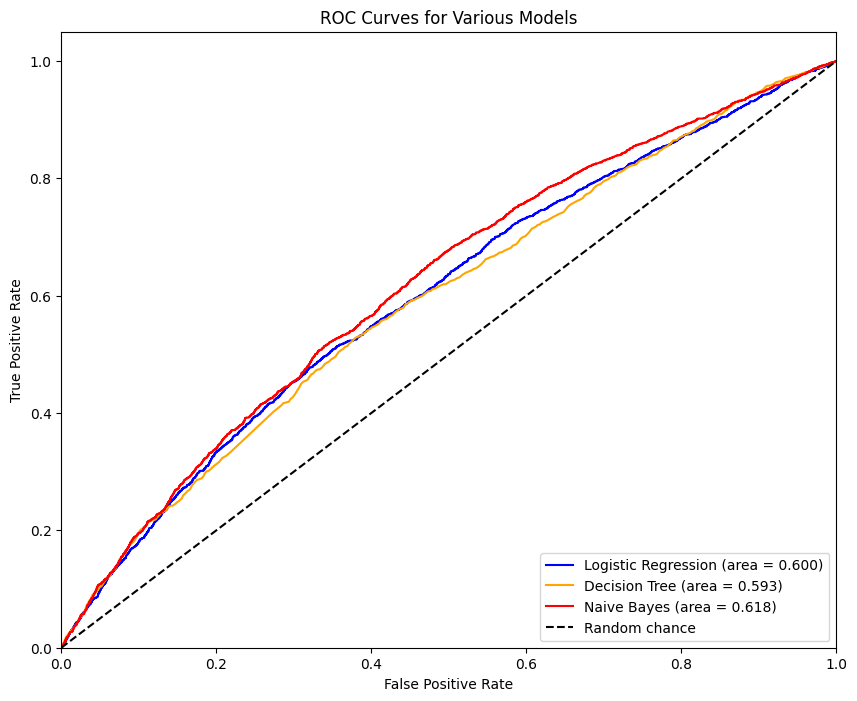

In [17]:

# Dictionary to hold ROC data
roc_data = {}

for name, model in models.items():
    model.fit(X_train, Y_train)
    Y_pred_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(Y_test, Y_pred_proba)
    roc_auc = metrics.roc_auc_score(Y_test, Y_pred_proba)
    roc_data[name] = (fpr, tpr, roc_auc)

# Plot ROC curves
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (area = {roc_auc:.3f})',color=colors[name])

plt.plot([0, 1], [0, 1], 'k--', label='Random chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Various Models')
plt.legend(loc="lower right")
plt.show()


Who is the winner?  
Lets take a look at other curves...

## Cumulative response and lift curves

Consider the following scenario:

Your boss tells you that you only have a \$5k budget.   Each mail costs $1 to send.  So this means you can only send the marketing to 2-3% of your customer base (191k).    

You want to use your model to determine which customers to send it to.  Where will you get the best lift over a random model?  


The **cumulative response curve** and its associated **lift curve** can provide this info : "How much better does my model do than random chance"?   The lift curve allows comments like **our best model improves our targeting by 4.5x**


Unfortunately, Python does not have a built in model to calculate these curves, so we will provide some user-built functions ...

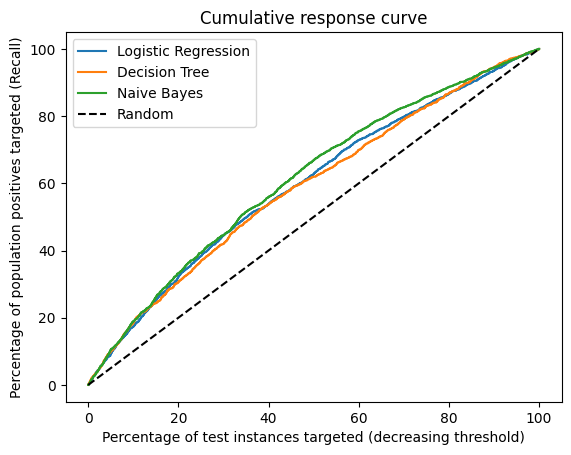

In [18]:
def build_cumulative_curve(model, scale=100):
    # Fit model
    model.fit(X_train, Y_train)

    # Get the probability of Y_test records being = 1
    Y_test_probs = model.predict_proba(X_test)[:, 1]

    # Sort these probabilities and the true value in descending order of probability
    order = np.argsort(Y_test_probs)[::-1]
    Y_test_probs_sorted = Y_test_probs[order]
    Y_test_sorted = np.array(Y_test)[order]

    # Build the cumulative response curve
    x_cumulative = np.arange(len(Y_test_probs_sorted)) + 1
    y_cumulative = np.cumsum(Y_test_sorted)

    # Rescale
    x_cumulative = np.array(x_cumulative)/float(x_cumulative.max()) * scale
    y_cumulative = np.array(y_cumulative)/float(y_cumulative.max()) * scale

    return x_cumulative, y_cumulative

def plot_cumulative_curve(models):
    # Plot curve for each model
    for key in models:
        x_cumulative, y_cumulative = build_cumulative_curve(models[key])
        plt.plot(x_cumulative, y_cumulative, label=key)
        # uncomment next lines to "zoom in"
        # plt.xlim(0, 5)  # Restrict x-axis to [0,10])
        #plt.ylim(0, 10)  # Restrict y-axis to [0,10])
    # Plot other details
    plt.plot([0,100], [0,100], 'k--', label="Random")
    plt.xlabel("Percentage of test instances targeted (decreasing threshold)")
    plt.ylabel("Percentage of population positives targeted (Recall)")
    plt.title("Cumulative response curve")
    plt.legend()

plot_cumulative_curve(models)

Lets zoom in on the left hand side to see what is happening if we only target 2-3% of our data?

Lets plot a **lift curve** to see exactly how much better we are doing than random.  What if we specfically only want to market to the top 1% of our customer base?  Which is best?

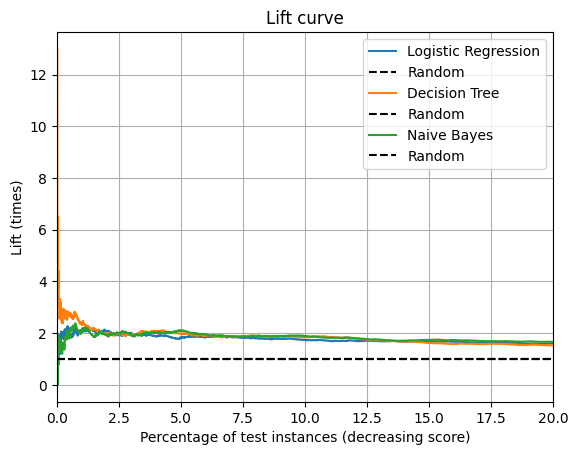

In [19]:
for key in models:
    # find the ratio between how our model does, and a random model
    # random model would catch x% of successes when targeting x% of customers
    x_cumulative, y_cumulative = build_cumulative_curve(models[key])
    plt.plot(x_cumulative, y_cumulative/x_cumulative, label=key)
    plt.plot([0,100], [1,1], 'k--', label="Random")
    plt.xlabel("Percentage of test instances (decreasing score)")
    plt.ylabel("Lift (times)")
    plt.title("Lift curve")
    plt.legend()
    plt.grid()
    # next line "focuses" on the left side of the curve
    plt.xlim(0, 20)  # Set x-axis limits to 0-20

# ZOOM IN!


## Profit curves

If we have extra knowledge about not just how much the mail costs, but how much we expect to get back from the offer, then we can start making decisions based on profit.  

Lets make some assumptions:

Let's say that each offer costs \$1 to make and market, and each accepted offer earns us an average of \$18, for a profit of $17. The cost matrix would be:

In [20]:
unit_cost = 1
unit_revenue = 18

cost_matrix = pd.DataFrame([[unit_revenue - unit_cost, - unit_cost], [0, 0]], columns=['Actual1', 'Actual0'], index=['Pred1', 'Pred0'])
print ("Cost matrix")
print (cost_matrix)

Cost matrix
       Actual1  Actual0
Pred1       17       -1
Pred0        0        0


Remember how we calculate profit - for one threshold:

In [21]:
print ("Confusion matrix with threshold =",thresh,"to send marketing:\n")
print (conf_mat)
print ("\n")
# print ("Confusion matrix with threshold = 5% to predict labels")
# print (confusion_matrix_5)

Confusion matrix with threshold = 0.08 to send marketing:

       Actual1  Actual0
Pred1      394     4127
Pred0     1533    31495




In [22]:
#multiply the confusion matrix by the cost matrix, element wise, and add up the values

import numpy as np
profit = np.sum(np.multiply(conf_mat.values, cost_matrix.values))
print("Profit: $",profit)


Profit: $ 2571


Now we can plot the profit curve across ALL thresholds....and we can do it for each of our three models

We will cycle through all possible thresholds and calculate the profit for each.  Note: this is not the most efficient way to write this code, but I think it is the easiest to understand.


Logistic Regression : Max Profit = 4249  with 0.328  % targeted

Decision Tree : Max Profit = 3776  with 0.336  % targeted

Naive Bayes : Max Profit = 4773  with 0.340  % targeted



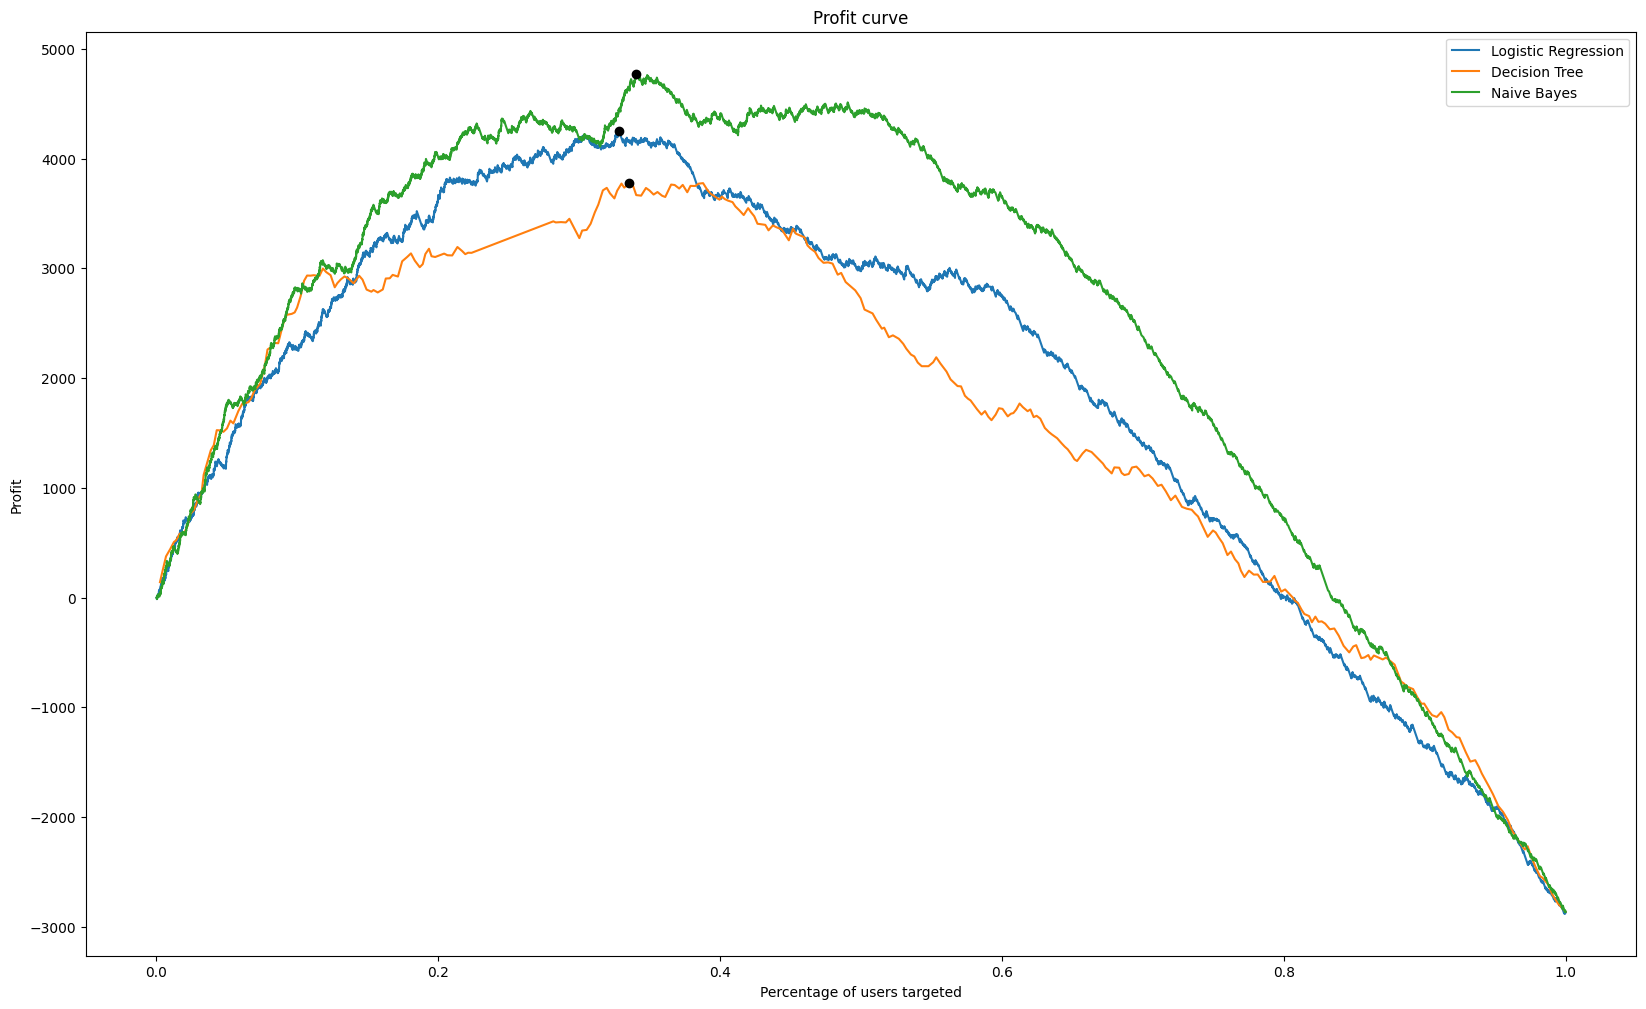

In [23]:
models = {
    'Logistic Regression': LogisticRegression(C=10000, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(criterion="entropy", max_depth = 15, min_samples_leaf=300, random_state=42),
    'Naive Bayes': GaussianNB(),
}

plt.figure(figsize=(20,12))
for key in models:
  model = models[key]
  model.fit(X_train, Y_train)

  ## sort your test data by probability of success
  probs = model.predict_proba(X_test)[:, 1]
  order = np.argsort(probs)[::-1]
  probs_sort = probs[order]
  Y_test_sort = np.array(Y_test)[order]


  ## set up some important values
  # these will store values for the plot
  xvec = []
  yvec = []

  # total cases in test data, and total "successes" in test data
  tot_obs = len(Y_test)
  tot_pos = Y_test.sum()
  max_profit = 0

  # cycle through the probability thresholds from highest to lowest
  for prob in probs_sort[:tot_obs]:
    # how many cases are above threshold?  These are cases predicted +
    pred_pos = probs_sort >= prob
    # how many cases that we predict + actually donated?
    num_donated_customers = Y_test_sort[pred_pos].sum()
    # now calculate the revenue,  the expense, and the profit
    expense = unit_cost * pred_pos.sum()
    revenue = unit_revenue * num_donated_customers
    profit = revenue - expense
    # points for Profit Curve: x=percent we predict + ; y=profit
    xval = pred_pos.sum()/tot_obs
    yval = profit
    # keep track of max profit
    if profit > max_profit:
      max_profit = profit
      max_profit_targeted = xval
    xvec.append(xval)
    yvec.append(yval)
  # print(prob, pred_pos.sum(), num_donated_customers, expense, revenue, profit)

  print(key, ": Max Profit = %.0f" % max_profit," with %.3f" %max_profit_targeted," % targeted\n")
  # format the print statement with 3 decimal place


  # plot xvec vs yvec
  plt.plot(xvec,yvec,label=key)
  plt.plot(max_profit_targeted, max_profit, 'ko')

plt.title("Profit curve")
plt.xlabel("Percentage of users targeted")
plt.ylabel("Profit")
plt.legend()
plt.show()


Which one do you think we should choose? Why?

Change your assumptions on cost/revenue...what happens to the curve?

## Do it yourself!

Lets say we wanted to optimize our values of max_depth and min_samples_leaf.  What function would we use to do that?

Change the parameters of the Decision Tree model (in the definition of `models` above) so that `max_depth = 7` and `min_samples_leaf = 100`.  Run the rest of the notebook.  Do you get the same answer for the model that optimizes profit?

Now change the cost matrix so that it costs more to send the marketing offer (\$2) but the benefit you get is more (\$25).  Note how the profit curves and optimal profit change.  Comment on the changes and propose an explanation.

